In [1]:
import numpy as np
import pandas as pd

# Generating data

y = (x * z)³

In [2]:
x_data = np.random.uniform(low=0, high=1.0, size=(3000,))
#z_data = np.random.standard_normal(size=(3000,))
z_data = np.random.uniform(low=0, high=1.0, size=(3000,))
pow_data = np.power(x_data * z_data, 1)
multi_data = x_data * z_data

df_power = pd.DataFrame(np.array([x_data, z_data, pow_data]).T, columns=['x_data', 'z_data', 'y_data'])
df_multi = pd.DataFrame(np.array([x_data, z_data, multi_data]).T, columns=['x_data', 'z_data', 'y_data'])
df_power

,x_data,z_data,y_data
0,0.444811,0.536520,0.238650
1,0.568766,0.202348,0.115089
2,0.844140,0.729933,0.616166
3,0.916048,0.664917,0.609096
4,0.395301,0.970416,0.383607
...,...,...,...
2995,0.343050,0.121895,0.041816
2996,0.876722,0.217575,0.190753
2997,0.145933,0.028830,0.004207
2998,0.637228,0.876354,0.558438


In [3]:
df_multi

,x_data,z_data,y_data
0,0.444811,0.536520,0.238650
1,0.568766,0.202348,0.115089
2,0.844140,0.729933,0.616166
3,0.916048,0.664917,0.609096
4,0.395301,0.970416,0.383607
...,...,...,...
2995,0.343050,0.121895,0.041816
2996,0.876722,0.217575,0.190753
2997,0.145933,0.028830,0.004207
2998,0.637228,0.876354,0.558438


In [4]:
import spice_net as spn

#spn.local_min(-4, 4, 0.05, 0.005, lambda x: x ** 2)

In [5]:


som_size = 50

som_1 = spn.SpiceNetSom(n_neurons=som_size,
                        value_range_start=-1.0,
                        value_range_end=1.0,
                        lrf_tuning_curve=spn.ConstLRF(0.8),
                        lrf_interaction_kernel=spn.ConstLRF(0.8),
                        make_2d_input=True)
som_2 = spn.SpiceNetSom(n_neurons=som_size,
                        value_range_start=df_power['y_data'].min(),
                        value_range_end=df_power['y_data'].max(),
                        lrf_tuning_curve=spn.ConstLRF(0.8),
                        lrf_interaction_kernel=spn.ConstLRF(0.8))

correlation_matrix = spn.SpiceNetHcm(som_1, som_2, spn.ConstLRF(0.8), spn.ConstLRF(0.8))

spice_net = spn.SpiceNet(correlation_matrix)

In [6]:
input_data = df_power[['x_data', 'z_data']].apply(lambda row: row.to_numpy(), axis=1).tolist()
spice_net.fit(input_data, df_power['y_data'].tolist(), 10, 10, print_output=True)


100%|██████████| 300/300 [00:46<00:00,  6.40it/s]

Time spend on the Components: 
Som: 31.974237203598022 s | Convolution Matrix: 14.659136772155762 s


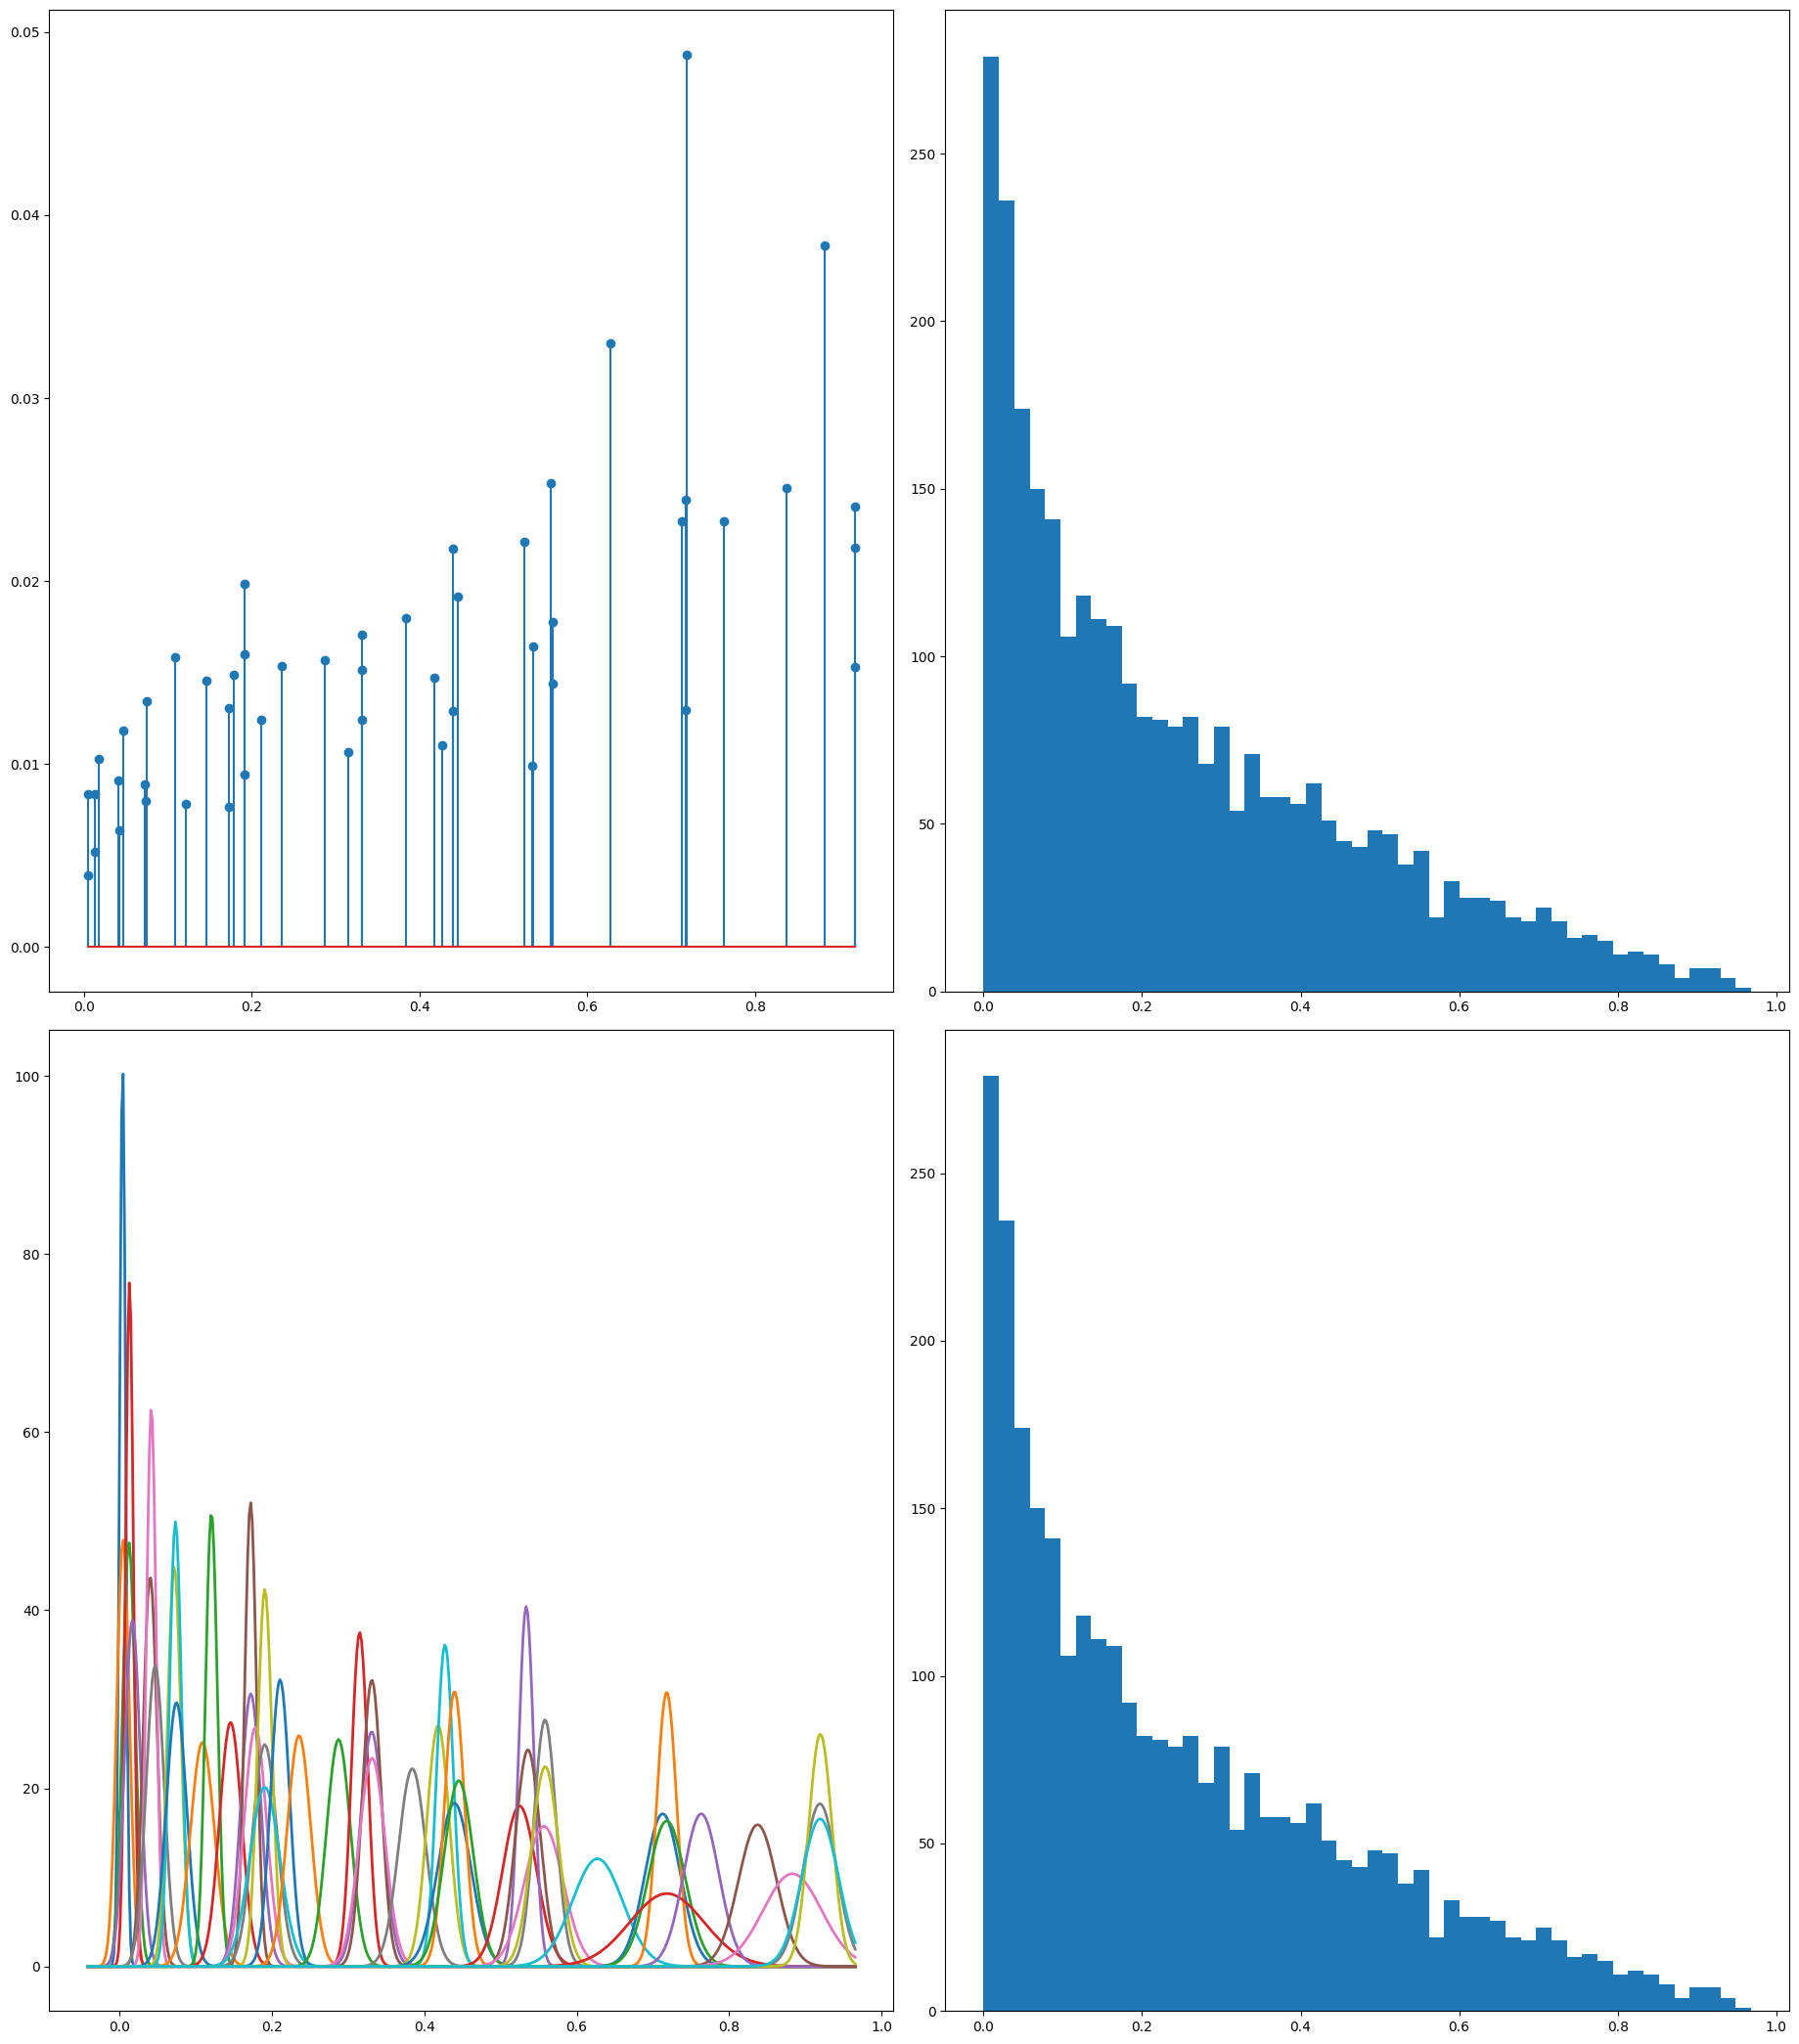

In [7]:
#spn.plot_som(som_1, True)
spn.plot_som(som_2, True)
spn.plot_hcm(correlation_matrix)
spn.plot_hcm(correlation_matrix, True)
spn.plot_som_comparison_to_data(som_2, df_power['y_data'].tolist())

In [8]:
errors = []

for i in range(100):
    test_data = df_power.sample()
    inti_test_value = test_data[['x_data', 'z_data']].iloc[0].to_numpy()
    result_test_value = test_data['y_data'].iloc[0]
    predicted = spice_net.decode(inti_test_value)
    errors.append(abs(predicted - result_test_value) / 2 * 100)
    print(f'Error: {errors[-1]:.6f},\t Predicted: {predicted:.6f},\t Actual: {result_test_value:.6f}')

print(f'Mean Error in % {np.mean(np.array(errors))}')
print(f'Median Error in % {np.median(np.array(errors))}')

Error: 1.783420,	 Predicted: 0.458416,	 Actual: 0.422747
Error: 8.404952,	 Predicted: 0.000013,	 Actual: 0.168112
Error: 19.493616,	 Predicted: 0.000302,	 Actual: 0.390174
Error: 3.714210,	 Predicted: 0.013488,	 Actual: 0.087772


ValueError: math domain error